Exploring the pre-computed features generated in the endo project by the diffusion autoencoder.

In [92]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import filters as skfilt
from scipy import interpolate as spinterp
from sklearn import decomposition as skdecomp

import cellsmap.util.io as io
import cellsmap.util.pca as cmpca
import cellsmap.analyses.playground.ea.utils.io as eaio
import cellsmap.analyses.playground.ea.utils.regression as eareg
import cellsmap.analyses.playground.ea.utils.viz as eaviz

In [93]:

df = pd.read_csv("/allen/aics/assay-dev/users/Erin/endo_features/pca_ref_features.csv", index_col=0)

In [94]:
df, reducer = cmpca.get_pca(df, num_pcs=3,scale=False)

df, _ = cmpca._get_outliers(df)
list_of_datasets = eaio.get_list_of_datasets(df,'group',verbose=True)

Cumulative Explained Variance: [0.7597 0.9142 0.9941]
List of datasets represented in feature data: 
20241120_20X
20241203_20X
20241210_20X
20241217_20X


In [95]:
df.head()

,0,1,2,3,4,5,6,7,start_x,start_y,group,T,FOV_ID,description,pca_ref,outlier
248400,-0.260010,-0.205200,0.370361,0.469727,-0.474854,-0.069580,-1.512695,-0.221191,0,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248401,-0.232422,-0.150757,0.591797,0.594727,-0.334473,0.029022,-1.418945,-0.106812,128,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248402,-0.178955,-0.148438,0.721680,0.719727,-0.136230,0.051239,-1.575195,-0.079895,256,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248403,-0.244873,-0.198853,0.945801,0.808594,-0.087524,0.037262,-1.524414,-0.090454,384,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248404,-0.274170,-0.196655,0.902832,0.770508,-0.175171,0.035126,-1.442383,-0.093018,512,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False


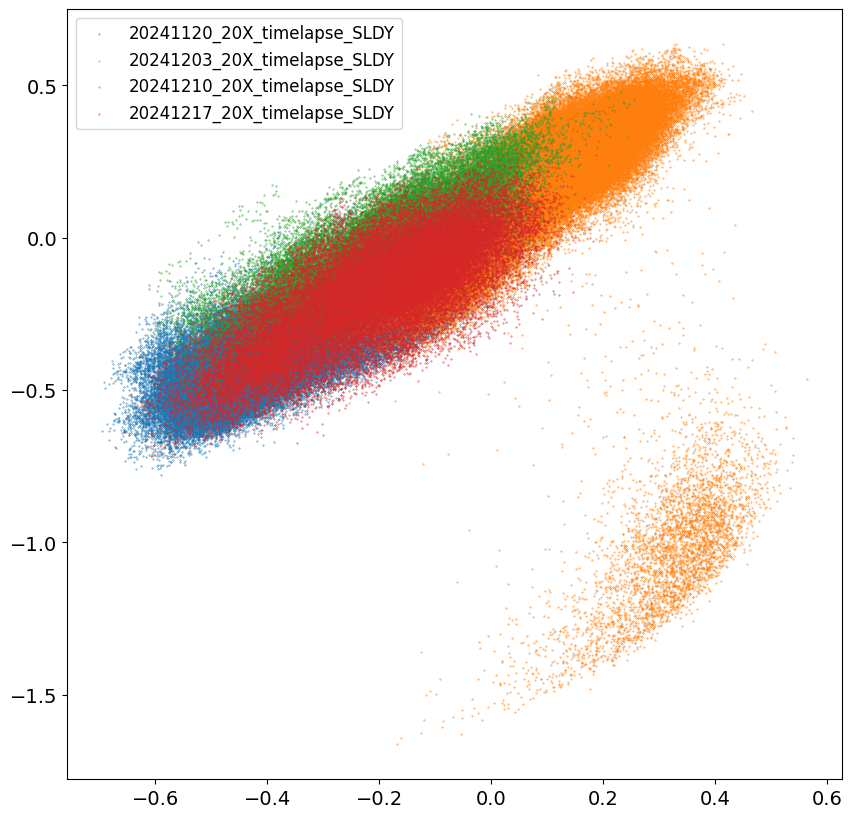

In [96]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
for (group, dfs) in df.groupby("group"):
    ax.scatter(dfs["1"], dfs["4"], s=0.1, label=group)
plt.legend()
plt.show()

In [97]:
df.loc[df.group.str.contains('20241210') & (df['T'] <= 300) & (df['T'] >= 450), 'outlier'] = True
df.loc[df.group.str.contains('20241217') & (df['T'] >= 100), 'outlier'] = True
df.loc[df.group.str.contains('20241217') & (df['T'] <= 300) & (df['T'] >= 420), 'outlier'] = True

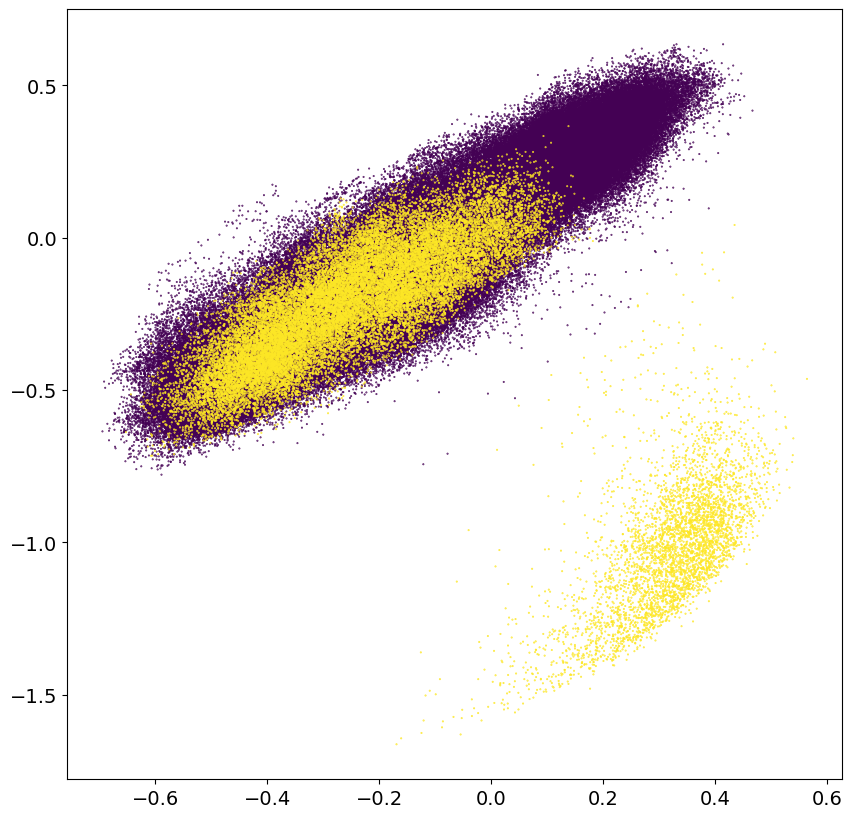

In [98]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.scatter(df["1"], df["4"], c=df['outlier'], s=0.2)
plt.show()

In [99]:
df = df.loc[df.outlier==False]

In [100]:
X = df[[str(u) for u in range(8)]].values
Xt = reducer.fit_transform(X)

In [101]:
for pc in range(3):
    df[f"PC{pc+1}"] = Xt[:, pc]
df["CropId"] = df["group"] + "_" + df["FOV_ID"].astype(str) + "_" + df["start_x"].astype(str) + "_" + df["start_y"].astype(str)
df.head()

,0,1,2,3,4,5,6,7,start_x,start_y,group,T,FOV_ID,description,pca_ref,outlier,PC1,PC2,PC3,CropId
248400,-0.260010,-0.205200,0.370361,0.469727,-0.474854,-0.069580,-1.512695,-0.221191,0,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.307865,-0.459138,-0.514003,20241120_20X_timelapse_SLDY_0_0_0
248401,-0.232422,-0.150757,0.591797,0.594727,-0.334473,0.029022,-1.418945,-0.106812,128,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.137903,-0.260376,-0.298697,20241120_20X_timelapse_SLDY_0_128_0
248402,-0.178955,-0.148438,0.721680,0.719727,-0.136230,0.051239,-1.575195,-0.079895,256,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.070882,-0.305880,0.003000,20241120_20X_timelapse_SLDY_0_256_0
248403,-0.244873,-0.198853,0.945801,0.808594,-0.087524,0.037262,-1.524414,-0.090454,384,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.129094,-0.109161,0.170755,20241120_20X_timelapse_SLDY_0_384_0
248404,-0.274170,-0.196655,0.902832,0.770508,-0.175171,0.035126,-1.442383,-0.093018,512,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.153558,-0.069063,0.048352,20241120_20X_timelapse_SLDY_0_512_0


In [102]:
df.description.unique()

array(['48hr High', '48hr Low', '48hr No Flow (12/10/24)',
       '48hr No Flow (12/17/24)'], dtype=object)

In [103]:
xmin, xmax = np.percentile(df.PC1, [0.1, 99.9])
ymin, ymax = np.percentile(df.PC2, [0.1, 99.9])
zmin, zmax = np.percentile(df.PC3, [0.1, 99.9])

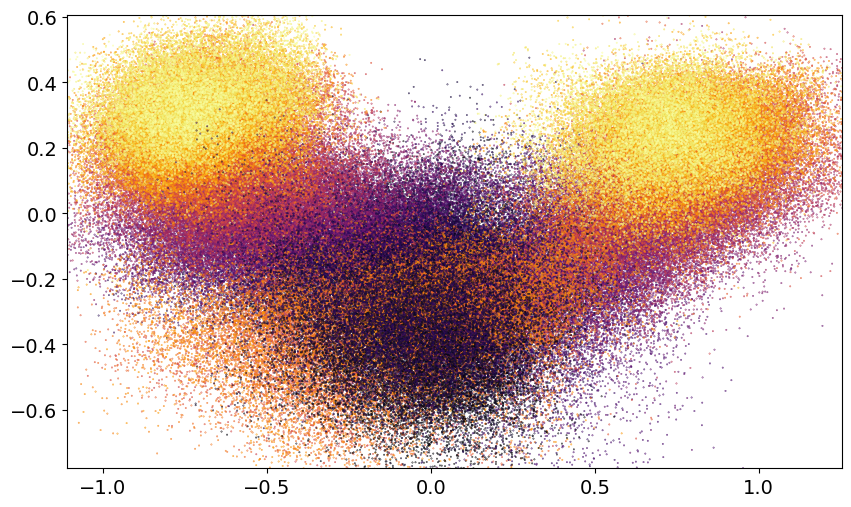

In [104]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(df.PC1, df.PC2, cmap="inferno", s=0.1, c=df["T"])
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
plt.show()

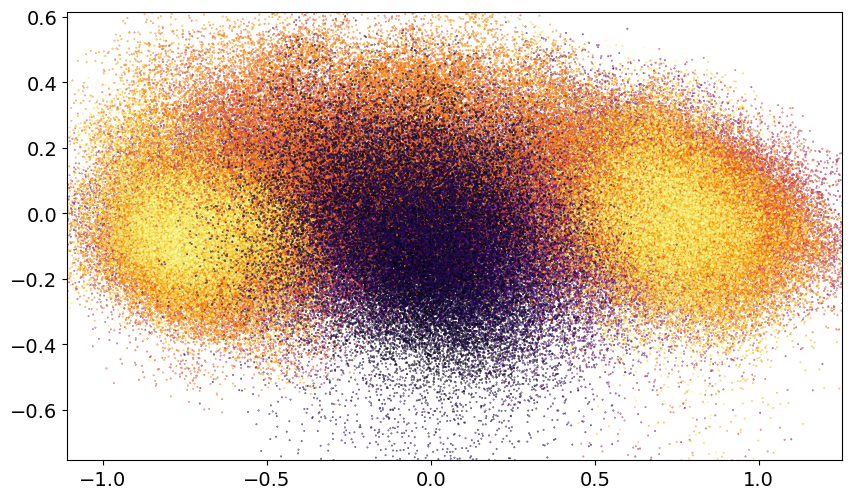

In [105]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(df.PC1, df.PC3, cmap="inferno", s=0.1, c=df["T"])
ax.set_xlim(xmin, xmax)
ax.set_ylim(zmin, zmax)
ax.set_aspect("equal")
plt.show()

/tmp/ipykernel_7458/2902552912.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(df.PC1, df.PC2, cmap="inferno", s=0.1, color="black", alpha=0.05)


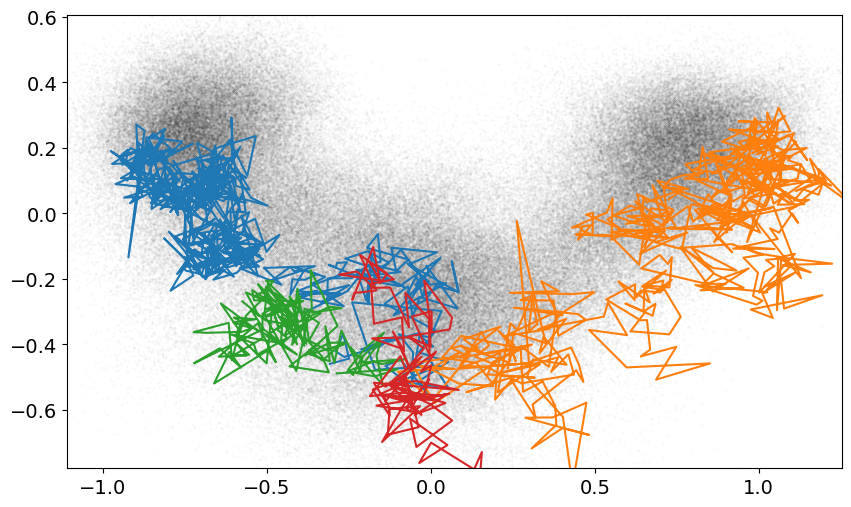

In [106]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(df.PC1, df.PC2, cmap="inferno", s=0.1, color="black", alpha=0.05)
for group, df_group in df.groupby("group"):
    for track, df_track in df_group.groupby("CropId"):
        ax.plot(df_track.PC1, df_track.PC2, label=group)
        break
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
plt.show()

In [107]:
df = df.sort_values(by=["group","CropId", "T"])
df.head()

,0,1,2,3,4,5,6,7,start_x,start_y,group,T,FOV_ID,description,pca_ref,outlier,PC1,PC2,PC3,CropId
248400,-0.260010,-0.205200,0.370361,0.469727,-0.474854,-0.069580,-1.512695,-0.221191,0,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.307865,-0.459138,-0.514003,20241120_20X_timelapse_SLDY_0_0_0
248616,-0.235596,-0.180908,0.376221,0.465820,-0.452881,-0.046021,-1.486328,-0.193359,0,0,20241120_20X_timelapse_SLDY,1,0,48hr High,True,False,-0.249529,-0.443144,-0.512917,20241120_20X_timelapse_SLDY_0_0_0
248832,-0.268311,-0.195435,0.487549,0.543945,-0.425537,-0.028931,-1.489258,-0.178711,0,0,20241120_20X_timelapse_SLDY,2,0,48hr High,True,False,-0.267681,-0.367180,-0.395959,20241120_20X_timelapse_SLDY_0_0_0
249048,-0.266357,-0.203125,0.464355,0.550293,-0.423096,-0.038818,-1.542969,-0.190186,0,0,20241120_20X_timelapse_SLDY,3,0,48hr High,True,False,-0.289799,-0.421312,-0.380170,20241120_20X_timelapse_SLDY_0_0_0
249264,-0.239014,-0.199707,0.522461,0.606934,-0.348877,-0.030258,-1.607422,-0.179932,0,0,20241120_20X_timelapse_SLDY,4,0,48hr High,True,False,-0.264176,-0.438143,-0.254606,20241120_20X_timelapse_SLDY_0_0_0


In [108]:
df_list = []
for group, df_group in df.groupby("group"):
    for crop, df_crop in df_group.groupby("CropId"):
        diff = np.diff(df_crop[["PC1", "PC2", "PC3"]].values,axis=0)
        dt = np.diff(df_crop["T"].values)
        big_jumps = np.where(dt>15)[0]
        dxdt= diff/dt[:,None]
        dxdt[big_jumps] = np.nan # remove vectors where difference is > 3 frames
        # divide by time difference to get velocity
        diff = np.vstack([dxdt,np.nan*np.ones(3)])
        diff = pd.DataFrame(data=diff, index=df_crop.index, columns=["dPC1", "dPC2", "dPC3"])
        df_list.append(pd.concat([df_crop, diff], axis=1))
df_vecs = pd.concat(df_list).dropna()

In [109]:
df_full = df_vecs.copy()
print(df_full.shape)

(297990, 23)


In [123]:
ds_desc = df.description.unique()
desc_id = 1
print("Visualizing for dataset:", ds_desc[desc_id])
df_vecs = df_full.copy()
df_vecs = df_vecs.loc[df_vecs.description==ds_desc[desc_id]]
print(df_vecs.shape)

Visualizing for dataset: 48hr Low
(120222, 23)


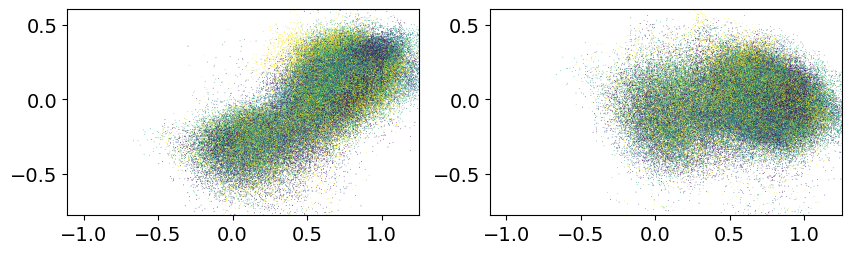

In [124]:
step = 1
U, V, Q, dU, dV, dQ = [df_vecs[col].values[::step] for col in ["PC1", "PC2", "PC3", "dPC1", "dPC2", "dPC3"]]
norm = np.sqrt(dU**2+dV**2+dQ**2)
dU = dU/norm
dV = dV/norm
dQ = dQ/norm
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.quiver(U, V, dU, dV, df_vecs.start_y.values[::step])
ax2.quiver(U, Q, dU, dQ, df_vecs.start_y.values[::step])
for ax in [ax1, ax2]:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
plt.show()

In [125]:
spacing = 0.05
x, y, z = np.linspace(xmin, xmax, int((xmax-xmin)/spacing)), np.linspace(ymin, ymax, int((ymax-ymin)/spacing)), np.linspace(zmin, zmax, int((zmax-zmin)/spacing))
xgrid, ygrid, zgrid = np.meshgrid(x,y,z, indexing='ij')
print(xgrid.shape, ygrid.shape, zgrid.shape)

(47, 27, 27) (47, 27, 27) (47, 27, 27)


In [126]:
# points = np.transpose(np.vstack((df_vecs.xi, df_vecs.yi)))
points = np.transpose(np.vstack((U, V, Q)))
dUi = spinterp.griddata(points, dU, (xgrid, ygrid, zgrid), method='linear', fill_value=0)
dVi = spinterp.griddata(points, dV, (xgrid, ygrid, zgrid), method='linear', fill_value=0)
dQi = spinterp.griddata(points, dQ, (xgrid, ygrid, zgrid), method='linear', fill_value=0)

In [127]:
dUis = skfilt.gaussian(dUi, sigma=3, preserve_range=True)
dVis = skfilt.gaussian(dVi, sigma=3, preserve_range=True)
dQis = skfilt.gaussian(dQi, sigma=3, preserve_range=True)

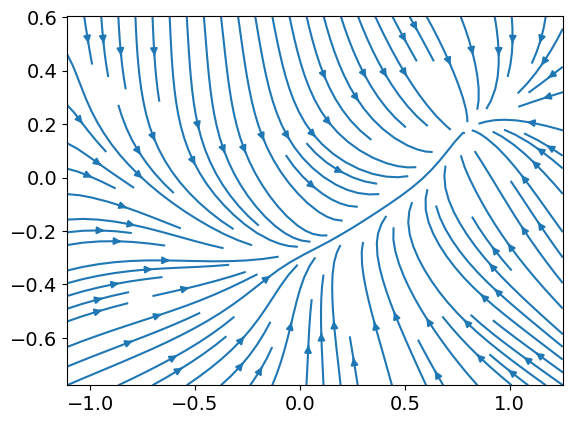

In [128]:
z_idx = np.argmin(abs(z-0)) # slice at z ~= 0
plt.streamplot(x, y, dUis[:,:,z_idx].T, dVis[:,:,z_idx].T)

2538


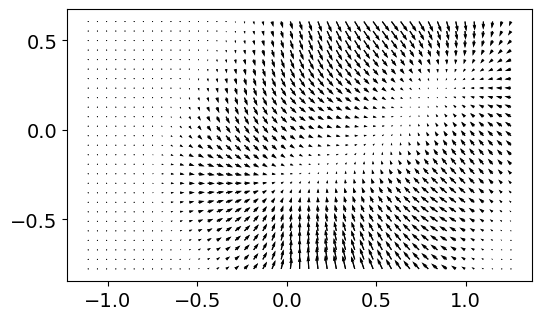

In [129]:
pc3val = 0.0
zgridmin = pc3val-0.8*spacing
zgridmax = pc3val+1.2*spacing
valids = np.where((zgrid.ravel()>zgridmin)&(zgrid.ravel()<zgridmax)); print(len(valids[0]))
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.quiver(xgrid.ravel()[valids], ygrid.ravel()[valids], dUis.ravel()[valids], dVis.ravel()[valids])
ax.set_aspect("equal")
plt.show()